# Problem 16: K-Nearest Neighbors (KNN) Classification - Euclidean Distance

**Objective**: Implement KNN classifier using Euclidean distance to classify data points based on their k nearest neighbors. Evaluate performance with different k values and visualize neighbor relationships.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
from scipy.spatial.distance import euclidean
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset - Iris-like flower classification
n_samples = 300
flower_species = np.random.choice([0, 1, 2], n_samples)

# Generate features based on species
sepal_length = np.where(flower_species == 0, np.random.normal(5.0, 0.4, n_samples),
                         np.where(flower_species == 1, np.random.normal(5.9, 0.5, n_samples),
                                  np.random.normal(6.6, 0.6, n_samples)))

sepal_width = np.where(flower_species == 0, np.random.normal(3.4, 0.4, n_samples),
                        np.where(flower_species == 1, np.random.normal(2.8, 0.3, n_samples),
                                 np.random.normal(2.9, 0.3, n_samples)))

petal_length = np.where(flower_species == 0, np.random.normal(1.5, 0.2, n_samples),
                         np.where(flower_species == 1, np.random.normal(4.3, 0.7, n_samples),
                                  np.random.normal(5.6, 0.6, n_samples)))

petal_width = np.where(flower_species == 0, np.random.normal(0.3, 0.1, n_samples),
                        np.where(flower_species == 1, np.random.normal(1.3, 0.2, n_samples),
                                 np.random.normal(2.0, 0.2, n_samples)))

# Ensure positive values
sepal_length = np.abs(sepal_length)
sepal_width = np.abs(sepal_width)
petal_length = np.abs(petal_length)
petal_width = np.abs(petal_width)

# Create DataFrame
df = pd.DataFrame({
    'sepal_length': sepal_length,
    'sepal_width': sepal_width,
    'petal_length': petal_length,
    'petal_width': petal_width,
    'species': flower_species
})

# Save to CSV
csv_path = 'knn_flowers.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")
print(f"Species distribution:")
print(df['species'].value_counts().sort_index())

Dataset created: knn_flowers.csv
Dataset shape: (300, 5)
Species distribution:
species
0     99
1     94
2    107
Name: count, dtype: int64


In [2]:
# Load and display dataset overview
df = pd.read_csv('knn_flowers.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   sepal_length  sepal_width  petal_length  petal_width  species
0      6.464996     3.663100      6.226515     2.080812        2
1      4.993714     3.955325      1.761645     0.375028        0
2      6.738292     2.871769      5.382944     1.934709        2
3      6.859385     2.803358      6.329193     1.849363        2
4      5.537267     3.492256      1.542328     0.370133        0

Dataset Shape: (300, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  300 non-null    float64
 1   sepal_width   300 non-null    float64
 2   petal_length  300 non-null    float64
 3   petal_width   300 non-null    float64
 4   species       300 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB
None

Dataset Statistics:
       sepal_length  sepal_width  petal_length  petal_width     species
count    

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check class distribution
print(f"\nClass distribution:")
print(df['species'].value_counts().sort_index())

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Duplicate rows: 0

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species           int64
dtype: object

Class distribution:
species
0     99
1     94
2    107
Name: count, dtype: int64

Dataset shape after cleaning: (300, 5)


## Exploratory Data Analysis (EDA)

Visualize the relationships between features and flower species.

C:\Users\hardi\AppData\Local\Temp\ipykernel_30428\1488347472.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([df[df['species'] == i]['petal_length'].values for i in range(3)],


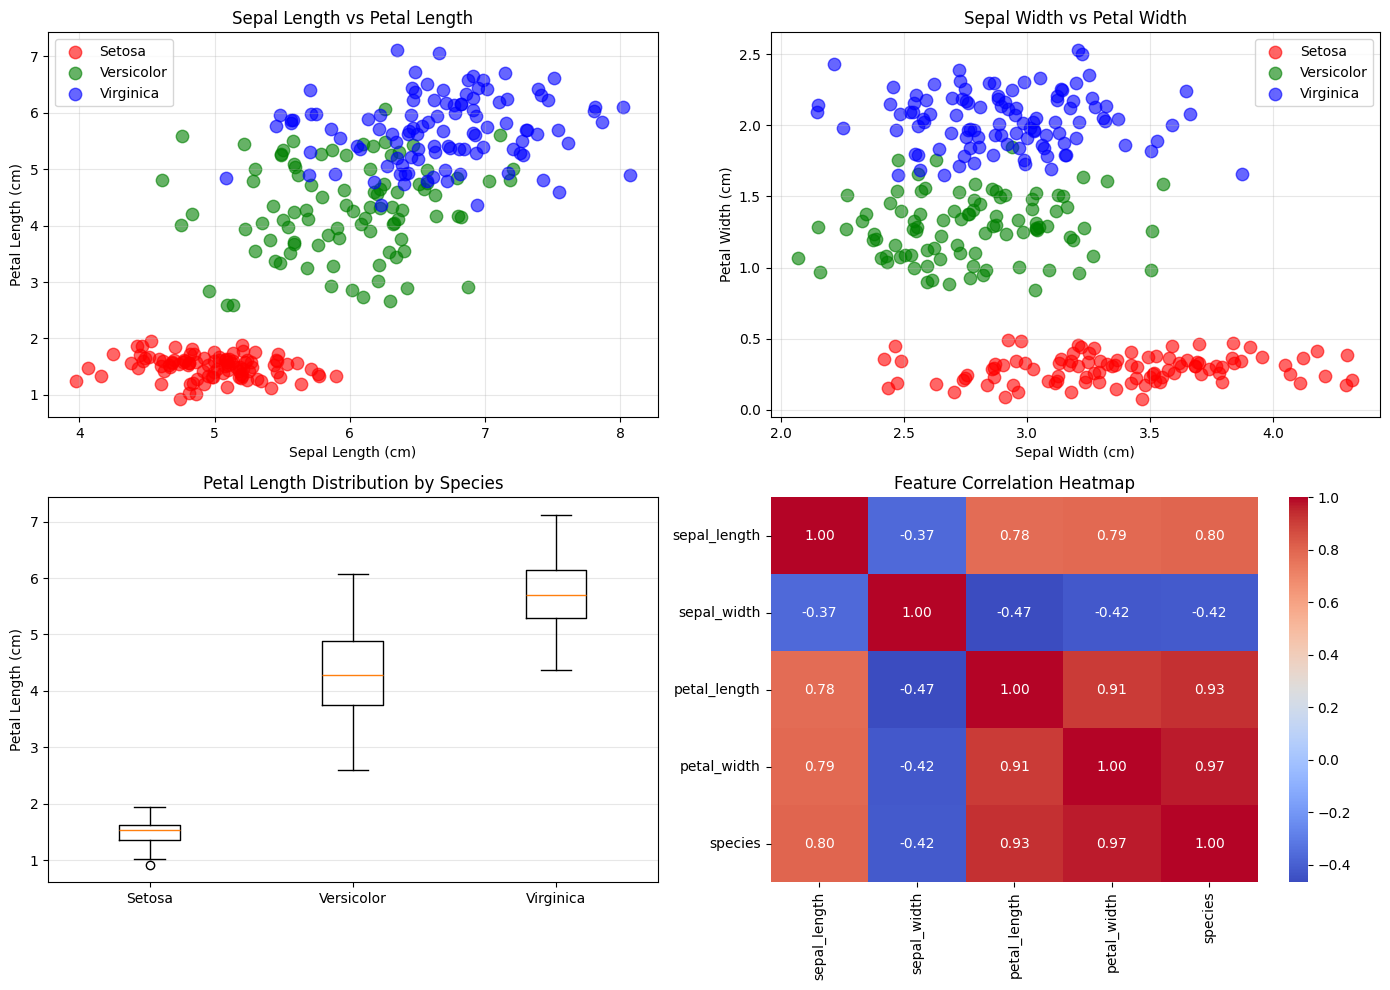

Feature Statistics:
       sepal_length  sepal_width  petal_length  petal_width     species
count    300.000000   300.000000    300.000000   300.000000  300.000000
mean       5.894095     3.018607      3.869370     1.223742    1.026667
std        0.874757     0.444029      1.857522     0.745489    0.829608
min        3.974263     2.070486      0.919695     0.074387    0.000000
25%        5.174345     2.716191      1.625723     0.352554    0.000000
50%        5.870987     2.972976      4.342316     1.290616    1.000000
75%        6.555676     3.267258      5.439344     1.928628    2.000000
max        8.072305     4.323117      7.117739     2.529629    2.000000


In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

species_names = ['Setosa', 'Versicolor', 'Virginica']
colors = ['red', 'green', 'blue']

# Scatter plot of sepal length vs petal length
for i, (species, color) in enumerate(zip(range(3), colors)):
    mask = df['species'] == species
    axes[0, 0].scatter(df[mask]['sepal_length'], df[mask]['petal_length'], 
                       label=species_names[i], alpha=0.6, color=color, s=80)
axes[0, 0].set_xlabel('Sepal Length (cm)')
axes[0, 0].set_ylabel('Petal Length (cm)')
axes[0, 0].set_title('Sepal Length vs Petal Length')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Scatter plot of sepal width vs petal width
for i, (species, color) in enumerate(zip(range(3), colors)):
    mask = df['species'] == species
    axes[0, 1].scatter(df[mask]['sepal_width'], df[mask]['petal_width'], 
                       label=species_names[i], alpha=0.6, color=color, s=80)
axes[0, 1].set_xlabel('Sepal Width (cm)')
axes[0, 1].set_ylabel('Petal Width (cm)')
axes[0, 1].set_title('Sepal Width vs Petal Width')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Feature distributions by species
axes[1, 0].boxplot([df[df['species'] == i]['petal_length'].values for i in range(3)],
                    labels=species_names)
axes[1, 0].set_ylabel('Petal Length (cm)')
axes[1, 0].set_title('Petal Length Distribution by Species')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Feature Statistics:")
print(df.describe())

## Feature Scaling

Normalize features using StandardScaler. This is critical for KNN as it uses distance-based metrics.

In [5]:
# Separate features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values
y = df['species'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Feature scaling completed
X shape: (300, 4)
y shape: (300,)

Scaled feature statistics:
X mean: 0.0000, std: 1.0000
Number of classes: 3
Class distribution: [ 99  94 107]


## Theory: K-Nearest Neighbors (KNN)

**K-Nearest Neighbors** is a simple, lazy learning algorithm that classifies data points based on their k nearest neighbors.

### Key Concepts:
- **Lazy Learning**: No training phase; learning occurs at prediction time
- **Distance Metric**: Typically Euclidean distance (can be Manhattan, Minkowski, etc.)
- **Voting Mechanism**:
  - Classification: Majority voting among k nearest neighbors
  - Regression: Average of k nearest neighbors' values
- **k Parameter**: Number of neighbors to consider

### Euclidean Distance:
For two points $p = (p_1, p_2, ..., p_n)$ and $q = (q_1, q_2, ..., q_n)$:
$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + ... + (p_n - q_n)^2}$$

### Decision Rule (Classification):
$$\hat{y} = \text{argmax}_c \sum_{i=1}^{k} \mathbb{1}(y_{nn_i} = c)$$

where $nn_i$ is the $i$-th nearest neighbor.

### Advantages:
- Simple to understand and implement
- No training phase (fast training)
- Works well with multi-class classification
- Non-parametric (no assumptions about data distribution)

### Disadvantages:
- Slow prediction time (computes distance to all training points)
- High memory usage (stores all training data)
- Sensitive to feature scaling
- Sensitive to irrelevant features (curse of dimensionality)
- k value selection is critical

## Mathematical Representation

**KNN Classification Algorithm**:

Given a test point $x_{test}$:

1. **Calculate distances** to all training points:
   $$D_i = \text{Euclidean}(x_{test}, x_i) \text{ for all } i = 1, ..., N$$

2. **Find k nearest neighbors**: Sort distances and select k smallest

3. **Classify by majority vote**:
   $$\hat{y}_{test} = \text{argmax}_c \sum_{i=1}^{k} \mathbb{1}(y_{nn_i} = c)$$

**Weighted KNN** (optional - distance-weighted voting):
$$w_i = \frac{1}{D_i}$$

$$\hat{y}_{test} = \text{argmax}_c \sum_{i=1}^{k} w_i \cdot \mathbb{1}(y_{nn_i} = c)$$

## Workflow Diagram

Visualize the complete KNN classification pipeline.

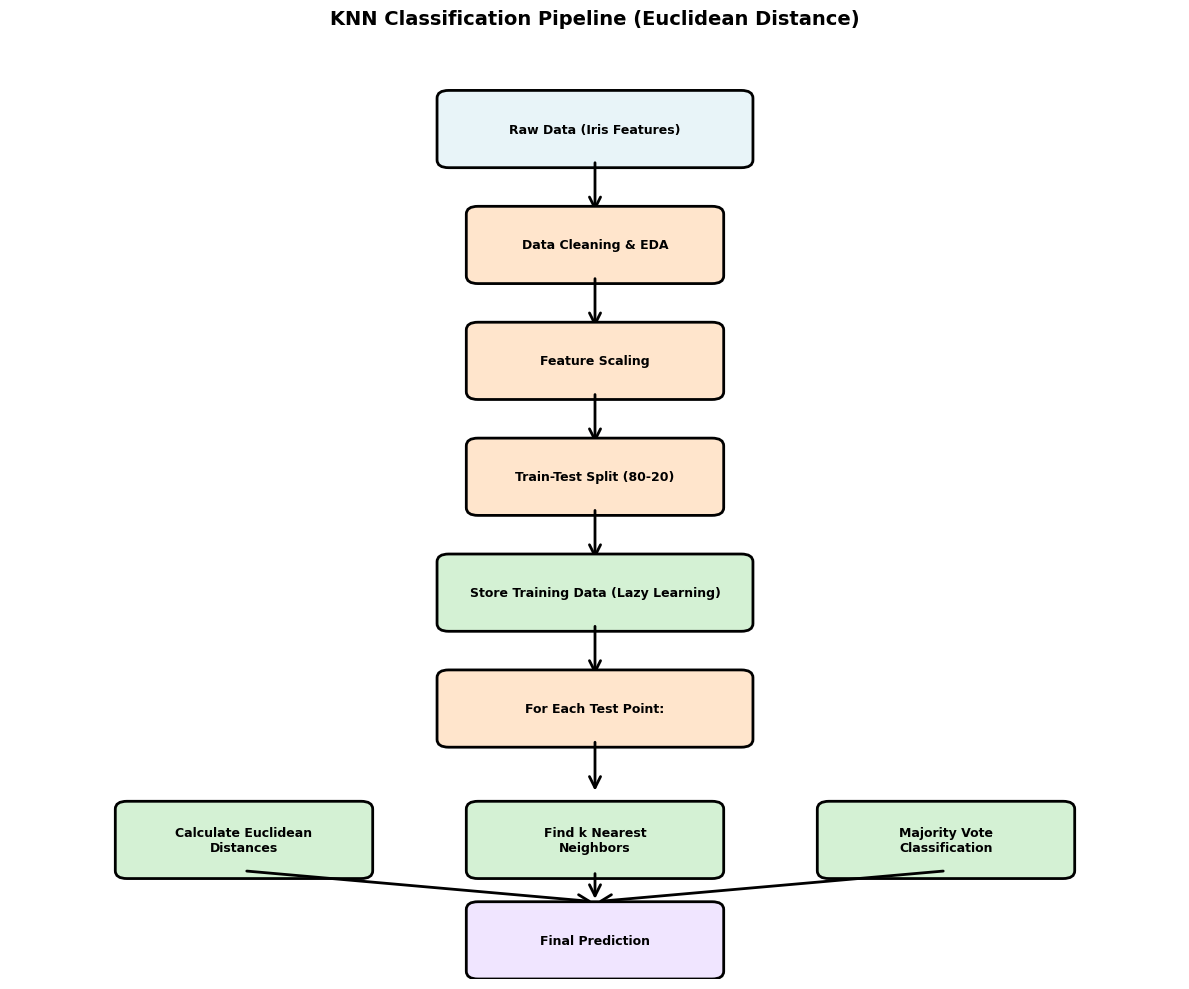

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_model = '#D4F1D4'
color_output = '#F0E5FF'

# Helper function to create boxes
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold', wrap=True)

# Helper function to create arrows
def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Create workflow
add_box(ax, 5, 11, 2.5, 0.8, 'Raw Data (Iris Features)', color_input)
add_arrow(ax, 5, 10.6, 5, 9.9)

add_box(ax, 5, 9.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 9.1, 5, 8.4)

add_box(ax, 5, 8, 2, 0.8, 'Feature Scaling', color_process)
add_arrow(ax, 5, 7.6, 5, 6.9)

add_box(ax, 5, 6.5, 2, 0.8, 'Train-Test Split (80-20)', color_process)
add_arrow(ax, 5, 6.1, 5, 5.4)

add_box(ax, 5, 5, 2.5, 0.8, 'Store Training Data (Lazy Learning)', color_model)
add_arrow(ax, 5, 4.6, 5, 3.9)

add_box(ax, 5, 3.5, 2.5, 0.8, 'For Each Test Point:', color_process)
add_arrow(ax, 5, 3.1, 5, 2.4)

add_box(ax, 2, 1.8, 2, 0.8, 'Calculate Euclidean\nDistances', color_model)
add_box(ax, 5, 1.8, 2, 0.8, 'Find k Nearest\nNeighbors', color_model)
add_box(ax, 8, 1.8, 2, 0.8, 'Majority Vote\nClassification', color_model)

add_arrow(ax, 2, 1.4, 5, 1.0)
add_arrow(ax, 5, 1.4, 5, 1.0)
add_arrow(ax, 8, 1.4, 5, 1.0)

add_box(ax, 5, 0.5, 2, 0.8, 'Final Prediction', color_output)

plt.title('KNN Classification Pipeline (Euclidean Distance)', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: K-Nearest Neighbors (KNN) Classifier
INPUT: Training data (X_train, y_train), Test data (X_test), k value

1. DATA PREPARATION
   - Load iris flower dataset
   - Clean data: remove missing values and duplicates
   - Perform EDA: visualize feature relationships

2. FEATURE SCALING
   - Apply StandardScaler to all features
   - IMPORTANT: Scale both training and test data using same scaler

3. TRAIN-TEST SPLIT
   - Split data: 80% training, 20% testing

4. KNN MODEL TRAINING (Lazy Learning)
   - Store training data and labels (no actual training)
   - Initialize KNN with k value

5. KNN PREDICTION FOR EACH TEST POINT
   FOR each test point x_test:
      a) Calculate Euclidean distance to all training points:
         d_i = sqrt((x_test - x_i)²) for all training points
      
      b) Find k smallest distances:
         neighbors = k training points with smallest distances
      
      c) Get labels of k nearest neighbors:
         neighbor_labels = labels of k neighbors
      
      d) Classify by majority vote:
         y_pred = most frequent class in neighbor_labels

6. EVALUATION
   - Calculate accuracy, precision, recall, F1 score
   - Generate confusion matrix
   - Test different k values to find optimal

7. VISUALIZATION
   - Plot decision boundaries (2D projection)
   - Visualize nearest neighbors for sample points
```

## Train-Test Split

Split the data into training and testing sets (80-20 split).

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nClass distribution in training set: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test set: {np.bincount(y_test.astype(int))}")

Training set size: 240
Testing set size: 60

Training set shape: X_train (240, 4), y_train (240,)
Testing set shape: X_test (60, 4), y_test (60,)

Class distribution in training set: [79 75 86]
Class distribution in test set: [20 19 21]


## KNN Model Training and Testing with Different k Values

Train KNN models with different k values and compare performance.

In [8]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 15, 20]
knn_models = {}
knn_results = {}

print("Training KNN models with different k values...")
print(f"{'='*70}")

for k in k_values:
    # Create and train KNN model
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)
    knn_models[k] = knn
    
    # Make predictions
    y_pred_train = knn.predict(X_train)
    y_pred_test = knn.predict(X_test)
    
    # Calculate metrics
    accuracy_train = accuracy_score(y_train, y_pred_train)
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision = precision_score(y_test, y_pred_test, average='weighted')
    recall = recall_score(y_test, y_pred_test, average='weighted')
    f1 = f1_score(y_test, y_pred_test, average='weighted')
    
    knn_results[k] = {
        'Train Accuracy': accuracy_train,
        'Test Accuracy': accuracy_test,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'Predictions': y_pred_test,
        'Confusion Matrix': confusion_matrix(y_test, y_pred_test)
    }
    
    print(f"k={k:2d}  |  Train Acc: {accuracy_train:.4f}  |  Test Acc: {accuracy_test:.4f}  |  F1: {f1:.4f}")

print(f"{'='*70}")

Training KNN models with different k values...
k= 1  |  Train Acc: 1.0000  |  Test Acc: 1.0000  |  F1: 1.0000
k= 3  |  Train Acc: 0.9917  |  Test Acc: 0.9667  |  F1: 0.9665
k= 5  |  Train Acc: 0.9917  |  Test Acc: 0.9667  |  F1: 0.9667
k= 7  |  Train Acc: 0.9917  |  Test Acc: 0.9667  |  F1: 0.9667
k= 9  |  Train Acc: 0.9917  |  Test Acc: 0.9667  |  F1: 0.9667
k=15  |  Train Acc: 0.9917  |  Test Acc: 0.9833  |  F1: 0.9833
k=20  |  Train Acc: 0.9917  |  Test Acc: 0.9833  |  F1: 0.9833


## Detailed Evaluation: Optimal k Value

Analyze performance metrics for all k values.

In [9]:
# Find optimal k
best_k = max(knn_results.items(), key=lambda x: x[1]['Test Accuracy'])[0]
print(f"Optimal k value: {best_k}")
print(f"\nBest model test accuracy: {knn_results[best_k]['Test Accuracy']:.6f}")

print(f"\n{'='*80}")
print(f"DETAILED METRICS FOR ALL K VALUES")
print(f"{'='*80}")
print(f"{'k':>3} | {'Train Acc':>10} | {'Test Acc':>10} | {'Precision':>10} | {'Recall':>10} | {'F1 Score':>10}")
print("-" * 80)

for k in k_values:
    print(f"{k:>3} | {knn_results[k]['Train Accuracy']:>10.6f} | {knn_results[k]['Test Accuracy']:>10.6f} | {knn_results[k]['Precision']:>10.6f} | {knn_results[k]['Recall']:>10.6f} | {knn_results[k]['F1 Score']:>10.6f}")

print(f"{'='*80}")

# Classification report for optimal k
print(f"\nClassification Report (k={best_k}):")
print(classification_report(y_test, knn_results[best_k]['Predictions'], 
                          target_names=['Setosa', 'Versicolor', 'Virginica']))

Optimal k value: 1

Best model test accuracy: 1.000000

DETAILED METRICS FOR ALL K VALUES
  k |  Train Acc |   Test Acc |  Precision |     Recall |   F1 Score
--------------------------------------------------------------------------------
  1 |   1.000000 |   1.000000 |   1.000000 |   1.000000 |   1.000000
  3 |   0.991667 |   0.966667 |   0.969565 |   0.966667 |   0.966498
  5 |   0.991667 |   0.966667 |   0.966667 |   0.966667 |   0.966667
  7 |   0.991667 |   0.966667 |   0.966667 |   0.966667 |   0.966667
  9 |   0.991667 |   0.966667 |   0.966667 |   0.966667 |   0.966667
 15 |   0.991667 |   0.983333 |   0.984091 |   0.983333 |   0.983302
 20 |   0.991667 |   0.983333 |   0.984091 |   0.983333 |   0.983302

Classification Report (k=1):
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        20
  Versicolor       1.00      1.00      1.00        19
   Virginica       1.00      1.00      1.00        21

    accuracy                 

## K Value Impact Visualization

Visualize how different k values affect model performance.

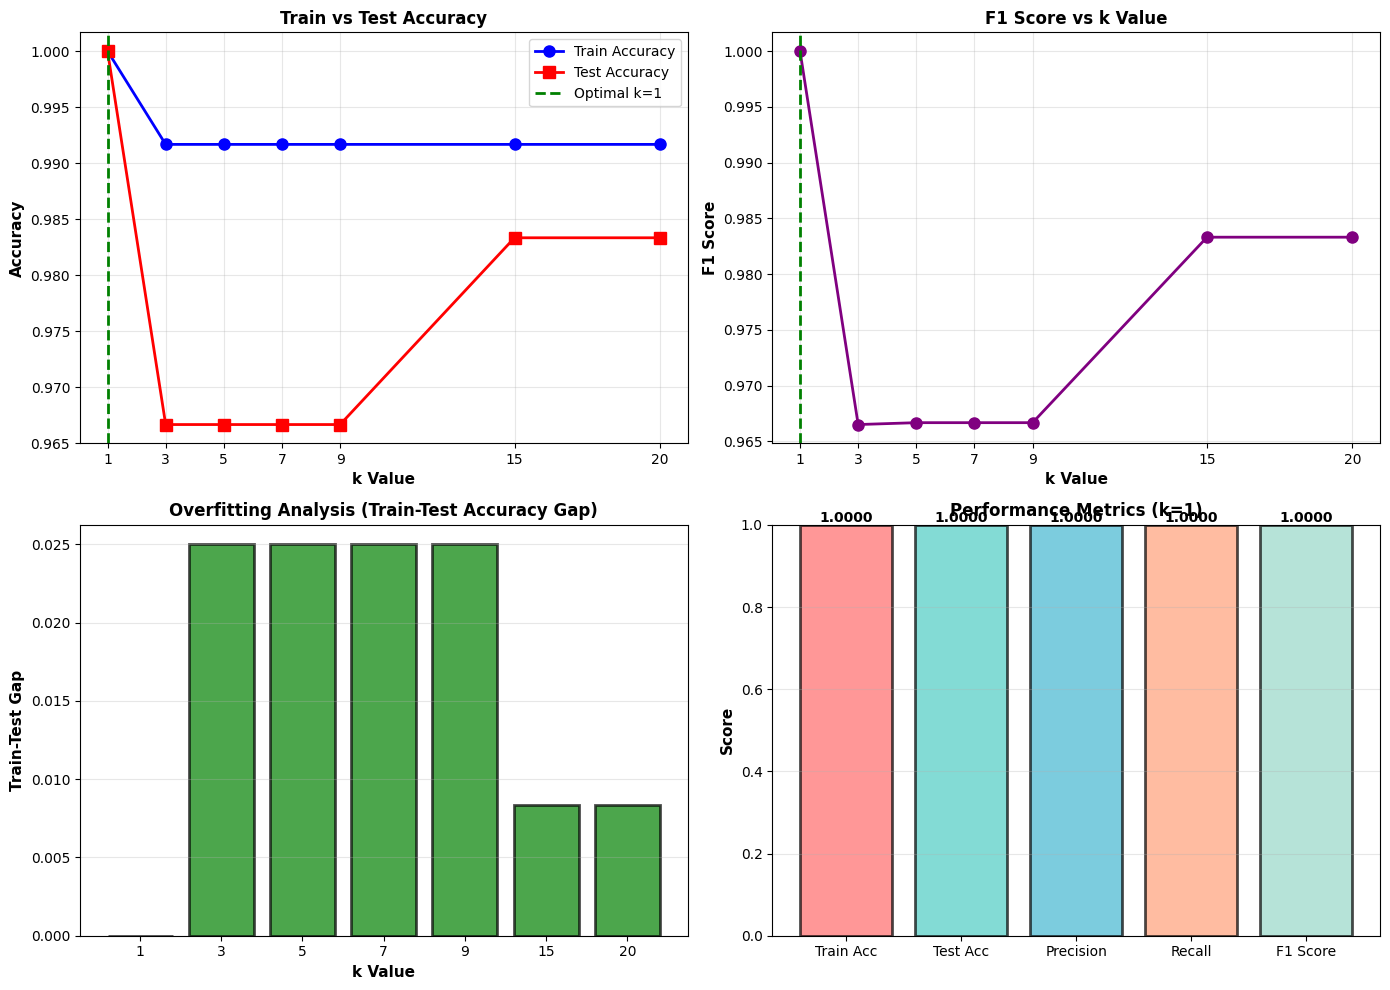

In [10]:
# Create comparison plots for different k values
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

train_accs = [knn_results[k]['Train Accuracy'] for k in k_values]
test_accs = [knn_results[k]['Test Accuracy'] for k in k_values]
f1_scores = [knn_results[k]['F1 Score'] for k in k_values]
precision_scores = [knn_results[k]['Precision'] for k in k_values]

# Plot 1: Train vs Test Accuracy
axes[0, 0].plot(k_values, train_accs, 'o-', color='blue', linewidth=2, markersize=8, label='Train Accuracy')
axes[0, 0].plot(k_values, test_accs, 's-', color='red', linewidth=2, markersize=8, label='Test Accuracy')
axes[0, 0].axvline(x=best_k, color='green', linestyle='--', linewidth=2, label=f'Optimal k={best_k}')
axes[0, 0].set_xlabel('k Value', fontsize=11, weight='bold')
axes[0, 0].set_ylabel('Accuracy', fontsize=11, weight='bold')
axes[0, 0].set_title('Train vs Test Accuracy', fontsize=12, weight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(k_values)

# Plot 2: F1 Score vs k
axes[0, 1].plot(k_values, f1_scores, 'o-', color='purple', linewidth=2, markersize=8)
axes[0, 1].axvline(x=best_k, color='green', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('k Value', fontsize=11, weight='bold')
axes[0, 1].set_ylabel('F1 Score', fontsize=11, weight='bold')
axes[0, 1].set_title('F1 Score vs k Value', fontsize=12, weight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(k_values)

# Plot 3: Overfitting Analysis
gap = [train_accs[i] - test_accs[i] for i in range(len(k_values))]
colors = ['red' if gap[i] > 0.1 else 'yellow' if gap[i] > 0.05 else 'green' for i in range(len(k_values))]
axes[1, 0].bar(range(len(k_values)), gap, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_xlabel('k Value', fontsize=11, weight='bold')
axes[1, 0].set_ylabel('Train-Test Gap', fontsize=11, weight='bold')
axes[1, 0].set_title('Overfitting Analysis (Train-Test Accuracy Gap)', fontsize=12, weight='bold')
axes[1, 0].set_xticks(range(len(k_values)))
axes[1, 0].set_xticklabels(k_values)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: All Metrics for Optimal k
metrics = ['Train Acc', 'Test Acc', 'Precision', 'Recall', 'F1 Score']
values = [
    knn_results[best_k]['Train Accuracy'],
    knn_results[best_k]['Test Accuracy'],
    knn_results[best_k]['Precision'],
    knn_results[best_k]['Recall'],
    knn_results[best_k]['F1 Score']
]
colors_metric = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8']
bars = axes[1, 1].bar(metrics, values, color=colors_metric, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 1].set_ylabel('Score', fontsize=11, weight='bold')
axes[1, 1].set_title(f'Performance Metrics (k={best_k})', fontsize=12, weight='bold')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}',
                   ha='center', va='bottom', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## Confusion Matrix: Optimal k

Visualize the confusion matrix for the optimal k value.

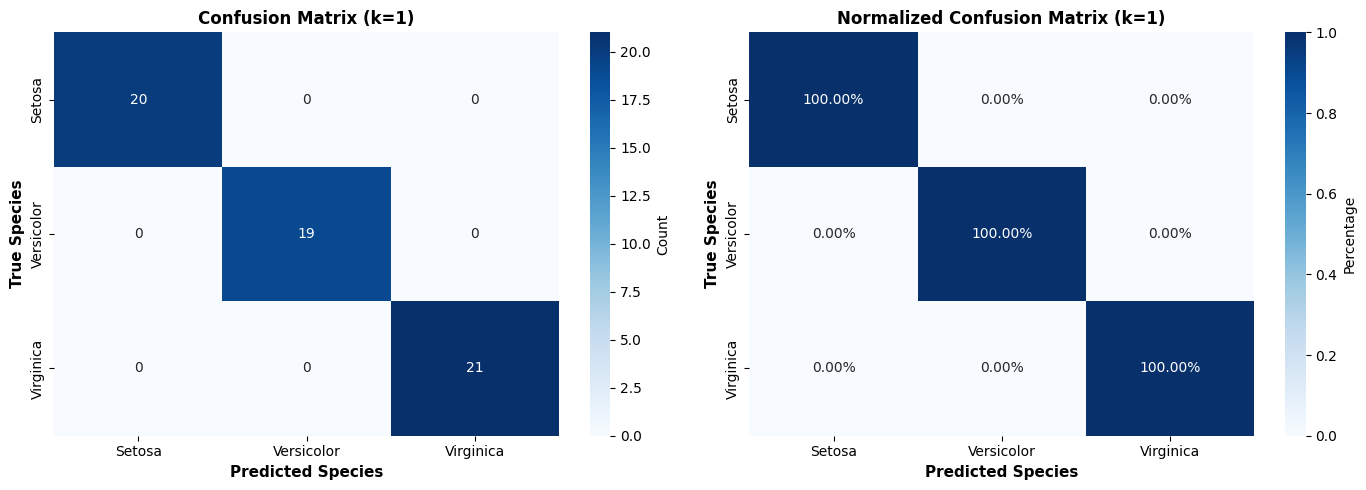

In [11]:
# Create confusion matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

species_names = ['Setosa', 'Versicolor', 'Virginica']
conf_matrix = knn_results[best_k]['Confusion Matrix']

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=species_names, yticklabels=species_names, cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Species', fontsize=11, weight='bold')
axes[0].set_ylabel('True Species', fontsize=11, weight='bold')
axes[0].set_title(f'Confusion Matrix (k={best_k})', fontsize=12, weight='bold')

# Plot 2: Normalized Confusion Matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=species_names, yticklabels=species_names, cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Species', fontsize=11, weight='bold')
axes[1].set_ylabel('True Species', fontsize=11, weight='bold')
axes[1].set_title(f'Normalized Confusion Matrix (k={best_k})', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Euclidean Distance Visualization

Demonstrate KNN classification using 2D projection with Euclidean distances.

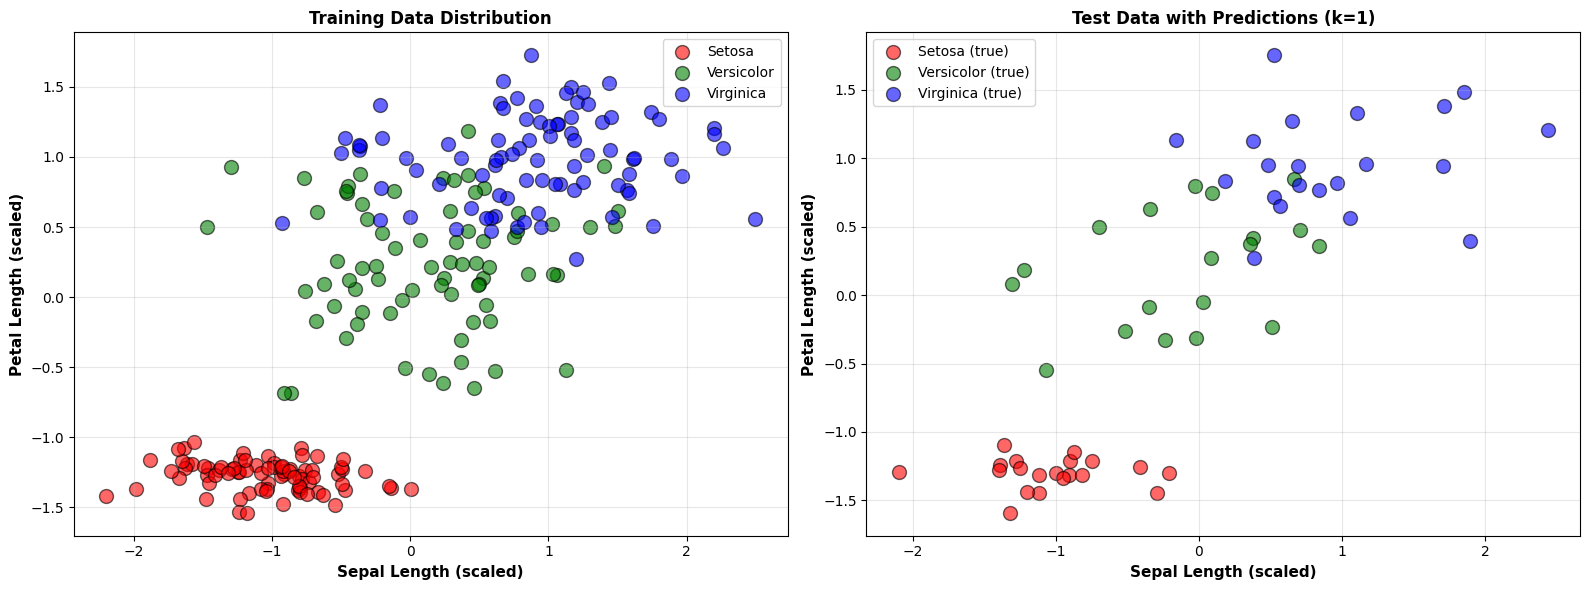


Correct Predictions: 60/60 (100.00%)
Misclassified: 0/60


In [12]:
# Create 2D visualization using first two features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Use sepal length and petal length for visualization
feature_x_idx = 0  # sepal_length
feature_y_idx = 2  # petal_length

species_colors = {0: 'red', 1: 'green', 2: 'blue'}
species_names = ['Setosa', 'Versicolor', 'Virginica']

# Plot 1: Training data
for species in range(3):
    mask = y_train == species
    axes[0].scatter(X_train[mask, feature_x_idx], X_train[mask, feature_y_idx],
                   label=species_names[species], alpha=0.6, s=100, 
                   color=species_colors[species], edgecolors='black', linewidth=1)

axes[0].set_xlabel(f'Sepal Length (scaled)', fontsize=11, weight='bold')
axes[0].set_ylabel(f'Petal Length (scaled)', fontsize=11, weight='bold')
axes[0].set_title('Training Data Distribution', fontsize=12, weight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Test data with predictions (k=best_k)
predictions = knn_models[best_k].predict(X_test)

for species in range(3):
    mask = y_test == species
    axes[1].scatter(X_test[mask, feature_x_idx], X_test[mask, feature_y_idx],
                   label=f'{species_names[species]} (true)', alpha=0.6, s=100,
                   color=species_colors[species], marker='o', edgecolors='black', linewidth=1)

# Mark misclassified points
misclassified = predictions != y_test
if misclassified.any():
    axes[1].scatter(X_test[misclassified, feature_x_idx], X_test[misclassified, feature_y_idx],
                   s=300, facecolors='none', edgecolors='red', linewidth=3,
                   label='Misclassified', marker='X')

axes[1].set_xlabel(f'Sepal Length (scaled)', fontsize=11, weight='bold')
axes[1].set_ylabel(f'Petal Length (scaled)', fontsize=11, weight='bold')
axes[1].set_title(f'Test Data with Predictions (k={best_k})', fontsize=12, weight='bold')
axes[1].legend(loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print accuracy
correct = (predictions == y_test).sum()
total = len(y_test)
print(f"\nCorrect Predictions: {correct}/{total} ({correct/total*100:.2f}%)")
print(f"Misclassified: {misclassified.sum()}/{total}")

## Nearest Neighbors Visualization

Show nearest neighbors for a sample test point.


NEAREST NEIGHBORS ANALYSIS (Sample Point 0)

True label: Versicolor
Predicted label: Versicolor

  k |  Neighbor Index | Euclidean Distance |           Label
----------------------------------------------------------------------
  1 |             212 |           0.380144 |      Versicolor


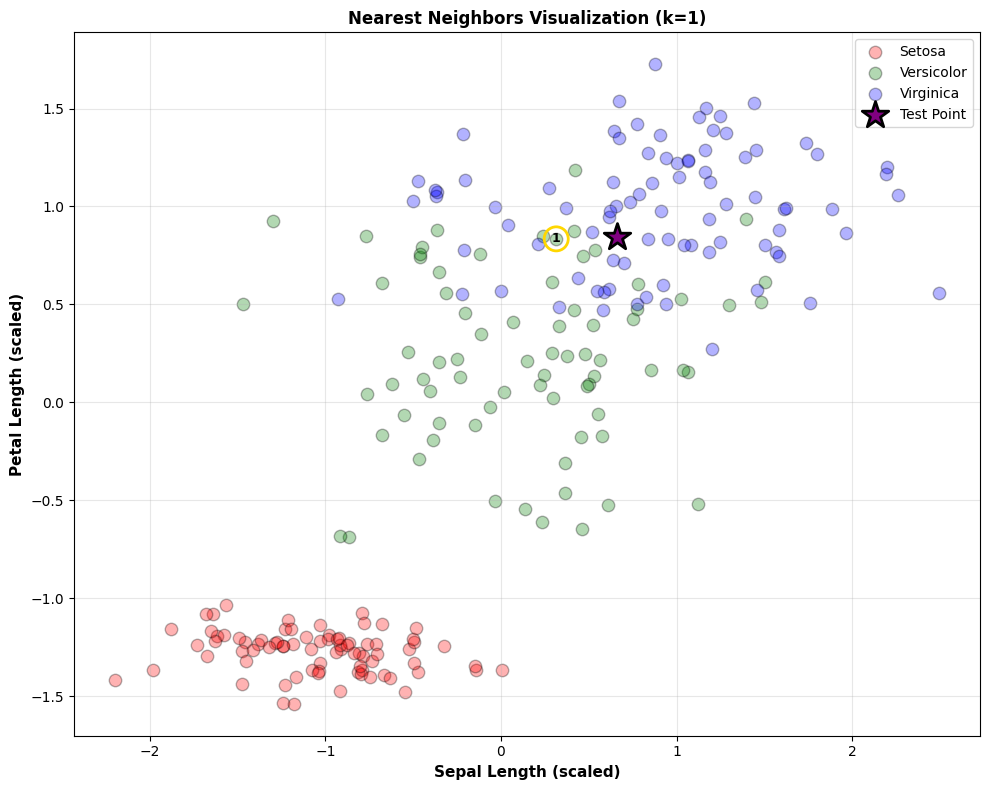

In [13]:
# Analyze nearest neighbors for a sample test point
sample_idx = 0
sample_point = X_test[sample_idx:sample_idx+1]
sample_label = y_test[sample_idx]

# Get k nearest neighbors
k = best_k
distances, indices = knn_models[best_k].kneighbors(sample_point)

print(f"\n{'='*70}")
print(f"NEAREST NEIGHBORS ANALYSIS (Sample Point {sample_idx})")
print(f"{'='*70}")
print(f"\nTrue label: {species_names[int(sample_label)]}")
print(f"Predicted label: {species_names[int(knn_models[best_k].predict(sample_point)[0])]}")

print(f"\n{'k':>3} | {'Neighbor Index':>15} | {'Euclidean Distance':>18} | {'Label':>15}")
print("-" * 70)

for i, (dist, idx) in enumerate(zip(distances[0], indices[0])):
    neighbor_label = y_train[idx]
    print(f"{i+1:>3} | {idx:>15} | {dist:>18.6f} | {species_names[int(neighbor_label)]:>15}")

print(f"{'='*70}")

# Visualize the sample and its neighbors
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Plot training data
for species in range(3):
    mask = y_train == species
    ax.scatter(X_train[mask, 0], X_train[mask, 2], alpha=0.3, s=80,
              color=species_colors[species], label=species_names[species], edgecolors='black')

# Highlight the k nearest neighbors
neighbor_indices = indices[0]
for i, idx in enumerate(neighbor_indices):
    ax.scatter(X_train[idx, 0], X_train[idx, 2], s=300, facecolors='none',
              edgecolors='gold', linewidth=2)
    ax.text(X_train[idx, 0], X_train[idx, 2], str(i+1), fontsize=9, weight='bold',
           ha='center', va='center')

# Plot the test point
ax.scatter(sample_point[0, 0], sample_point[0, 2], s=400, marker='*',
          color='purple', edgecolors='black', linewidth=2, label='Test Point', zorder=5)

ax.set_xlabel('Sepal Length (scaled)', fontsize=11, weight='bold')
ax.set_ylabel('Petal Length (scaled)', fontsize=11, weight='bold')
ax.set_title(f'Nearest Neighbors Visualization (k={best_k})', fontsize=12, weight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Model Persistence and Predictions

Save the optimal KNN model and demonstrate predictions on new data.

In [14]:
# Save the optimal model and scaler
model_path = f'knn_best_model_k{best_k}.joblib'
scaler_path = 'scaler_knn.joblib'

joblib.dump(knn_models[best_k], model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ KNN model (k={best_k}) saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Example: Predict for new data
new_data = np.array([
    [5.0, 3.4, 1.5, 0.3],   # Likely Setosa
    [5.9, 2.8, 4.3, 1.3],   # Likely Versicolor
    [6.6, 2.9, 5.6, 2.0]    # Likely Virginica
])

new_data_scaled = scaler.transform(new_data)
new_predictions = knn_models[best_k].predict(new_data_scaled)
new_probas = knn_models[best_k].predict_proba(new_data_scaled)
new_distances, new_indices = knn_models[best_k].kneighbors(new_data_scaled)

print(f"\n{'='*80}")
print("PREDICTIONS FOR NEW DATA")
print(f"{'='*80}")
print(f"{'Sepal L':>10} | {'Sepal W':>10} | {'Petal L':>10} | {'Petal W':>10} | {'Predicted':>12} | {'Confidence':>12}")
print("-" * 80)

for i in range(len(new_data)):
    confidence = np.max(new_probas[i])
    pred_name = species_names[new_predictions[i]]
    print(f"{new_data[i][0]:>10.1f} | {new_data[i][1]:>10.1f} | {new_data[i][2]:>10.1f} | {new_data[i][3]:>10.1f} | {pred_name:>12} | {confidence:>11.2%}")

print(f"{'='*80}")
print("\n✓ KNN Classification with Euclidean Distance completed successfully!")

✓ KNN model (k=1) saved to: knn_best_model_k1.joblib
✓ Scaler saved to: scaler_knn.joblib

PREDICTIONS FOR NEW DATA
   Sepal L |    Sepal W |    Petal L |    Petal W |    Predicted |   Confidence
--------------------------------------------------------------------------------
       5.0 |        3.4 |        1.5 |        0.3 |       Setosa |     100.00%
       5.9 |        2.8 |        4.3 |        1.3 |   Versicolor |     100.00%
       6.6 |        2.9 |        5.6 |        2.0 |    Virginica |     100.00%

✓ KNN Classification with Euclidean Distance completed successfully!
